# Модель предсказания массы морских черепах по биометрическим параметрам

Выполнил: **Клюев Дмитрий Алексеевич 07.05.2026**

## Заголовок
- Разработка модели линейной регрессии для предсказания массы черепах на основе их габаритных размеров и других характеристик

## Постановка задачи машинного обучения

- **Тип задачи:** Регрессия (предсказание непрерывного числового значения)
- **Целевая переменная:** `weight` (масса черепахи, кг)
- **Метрики качества модели:**
  - **RMSE** (Root Mean Square Error) — основная метрика, показывает среднеквадратичную ошибку в кг
  - **MAPE** (Mean Absolute Percentage Error) — средняя абсолютная процентная ошибка
  - **R²** (коэффициент детерминации) — доля объяснённой дисперсии

## Подключение и настройка библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

print("Библиотеки успешно подключены")

Библиотеки успешно подключены


## Загрузка датасета

**Датасет был взят на платформе Яндекс.Практикум** 
https://code.s3.yandex.net/datasets/turtles.csv

Описание датасета:
id — идентификатор измерения.
binomial_name — международное научное название вида черепахи.
registration_number — регистрационный номер черепахи.
shell_length — длина панциря, мм.
shell_width — ширина панциря, мм.
head_length — длина головы, мм.
head_width — ширина головы, мм.
flipper_length_n — длина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо n указан номер от 1 до 4.
flipper_width_n — ширина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо n указан номер от 1 до 4.
circle_count — количество колец роста на панцире черепахи.
measure_count — количество измерений по модели компьютерного зрения перед усреднением показателей.
shell_crack — наличие трещин панциря.
timestamp — время внесения данных о черепахе.
weight — масса черепахи, кг.


In [2]:
# Загрузка данных
df = pd.read_csv('https://code.s3.yandex.net/datasets/turtles.csv', sep='\t', decimal=',')

# Проверка загрузки
print("Размер датасета:", df.shape)
print("\nПервые 30 строк:")
display(df.head(30))

print("\nИнформация о данных:")
df.info()

print("\nСтатистическое описание:")
display(df.describe())

print("\nПроверка пропусков:")
print(df.isnull().sum())

print("\nПроверка дубликатов:")
print(f"Количество дубликатов: {df.duplicated().sum()}")

# Проверка корректности данных
print("\nПроверка типов данных:")
print(df.dtypes)

# Анализ проблем в данных
problems = []

# Проверка на отрицательные значения в габаритах
gabarites_cols = ['shell_length', 'shell_width', 'head_length', 'head_width'] + \
                 [f'flipper_length_{i}' for i in range(1,5)] + \
                 [f'flipper_width_{i}' for i in range(1,5)]

for col in gabarites_cols:
    if col in df.columns:
        if (df[col] < 0).any():
            problems.append(f"Отрицательные значения в {col}")

# Проверка выбросов
for col in gabarites_cols:
    if col in df.columns:
        # Если есть значения > 1000 мм (1 метр) для черепах, это подозрительно
        if (df[col] > 1000).any():
            problems.append(f"Возможно некорректные значения (умножены на 10) в {col}")

# Вывод о возможности продолжения работы
if problems:
    print("\nОбнаружены проблемы с данными. Требуется предобработка:")
    for p in problems:
        print(f"  - {p}")
    print("\nНеобходимо исправить проблемы перед построением модели.")
else:
    print("\nДанные загружены корректно. Можно продолжать работу.")

Размер датасета: (8861, 20)

Первые 30 строк:


,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.000,381,112.000,82.000,356,205,331,185,270.000,180.000,273.000,144.000,63,3.000,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.000,295,65.000,48.000,216,190,229,186,164.000,182.000,180.000,149.000,0,1.000,1.000,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.000,343,71.000,70.000,308,224,285,232,264.000,179.000,268.000,176.000,0,3.000,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.000,432,98.000,95.000,334,317,364,284,NaN,NaN,NaN,NaN,3,4.000,1.000,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.000,307,50.000,54.000,280,168,269,218,199.000,165.000,209.000,180.000,0,4.000,1.000,1744455613,28.511
5,25045,Lepidochelys olivacea,1b076bdf8f9ed92f370f64ffd28b7dd6,341.000,254,54.000,55.000,250,204,240,217,197.000,152.000,185.000,154.000,0,1.000,NaN,1749366080,27.513
6,23228,Lepidochelys olivacea,ad587cf0ebf5ac3a337fc55f91b16086,606.000,526,114.000,91.000,489,407,460,316,440.000,260.000,326.000,300.000,32,2.000,NaN,1731882409,40.228
7,19458,Lepidochelys olivacea,a9d0a18fc14b993b95ea02a314aa4aee,600.000,551,104.000,109.000,411,328,396,338,356.000,258.000,321.000,266.000,20,3.000,NaN,1693572979,38.838
8,25241,Chelonia mydas,0d05dca974d9f624d9c9f8e38817f827,742.000,652,118.000,147.000,411,386,507,389,414.000,368.000,311.000,325.000,66,4.000,1.000,1751228603,56.352
9,20199,Lepidochelys olivacea,baa40598df8e5120e81c65a847a5a5be,399.000,336,NaN,NaN,264,240,288,234,215.000,161.000,226.000,186.000,0,4.000,NaN,1700915750,29.823



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   object 
 2   registration number  8832 non-null   object 
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count    

,id,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
count,8861.000,8774.000,8861.000,8715.000,8715.000,8861.000,8861.000,8861.000,8861.000,8760.000,8760.000,8760.000,8760.000,8861.000,8597.000,2176.000,8861.000,8842.000
mean,21359.336,764.222,598.832,123.341,115.735,497.551,380.595,498.229,380.688,397.953,304.405,397.853,305.030,41.003,2.477,1.671,1712640020.543,79.163
std,2263.089,640.409,480.970,67.837,62.326,353.575,214.482,355.075,213.485,282.971,171.172,281.984,171.541,36.996,1.117,1.132,22922731.301,95.878
min,17438.000,132.000,78.000,19.000,12.000,60.000,34.000,57.000,33.000,50.000,27.000,44.000,25.000,0.000,1.000,1.000,1672570071.000,0.000
25%,19396.000,440.000,341.000,73.000,67.000,296.000,228.000,296.000,229.000,239.000,182.000,236.000,183.000,0.000,1.000,1.000,1693001223.000,31.110
50%,21357.000,635.000,487.000,106.000,98.000,416.000,332.000,417.000,330.000,333.000,264.000,333.000,266.000,35.000,2.000,1.000,1712803975.000,41.141
75%,23317.000,951.000,794.000,158.000,156.000,571.000,493.000,572.000,500.000,457.000,397.000,456.000,396.000,73.000,3.000,2.000,1732901717.000,85.239
max,25279.000,20240.000,11550.000,515.000,382.000,2875.000,1479.000,2967.000,1402.000,2279.000,1280.000,2406.000,1313.000,178.000,4.000,5.000,1751607559.000,617.777



Проверка пропусков:
id                        0
binomial_name            49
registration number      29
shell_length             87
shell_width               0
head_length             146
head_width              146
flipper_length_1          0
flipper_width_1           0
flipper_length_2          0
flipper_width_2           0
flipper_length_3        101
flipper_width_3         101
flipper_length_4        101
flipper_width_4         101
circle_count              0
measure_count           264
shell_crack            6685
timestamp                 0
weight                   19
dtype: int64

Проверка дубликатов:
Количество дубликатов: 1019

Проверка типов данных:
id                       int64
binomial_name           object
registration number     object
shell_length           float64
shell_width              int64
head_length            float64
head_width             float64
flipper_length_1         int64
flipper_width_1          int64
flipper_length_2         int64
flipper_width_2       

## Выводы по загрузке данных

### 1. Корректность загрузки
- Данные успешно загружены с правильными параметрами `sep='\t'` и `decimal=','`
- Размерность датасета: 8861 строк × 20 столбцов — соответствует ожидаемой

### 2. Структура данных
- **Типы данных:** 
  - 8 целочисленных (`int64`) признаков
  - 10 вещественных (`float64`) признаков
  - 2 категориальных (`object`) признака (`binomial_name`, `registration number`)
- **Целевая переменная:** `weight` (`float64`) — масса черепахи в кг

### 3. Проблемы с данными

#### Критические проблемы:
- **Некорректные масштабы измерений:** Максимальные значения в признаках-габаритах аномально высоки:
  - `shell_length` до 20240 мм (20.24 м) — явно умножено на 10
  - `shell_width` до 11550 мм (11.55 м) — умножено на 10
  - Длины ласт до 2875 мм (2.875 м) — умножено на 10
  - Ширина ласт до 1479 мм (1.479 м) — умножено на 10
  - *Требуется:* разделить все аномальные значения на 10

#### Существенные проблемы:
- **Пропуски в данных:**
  - `shell_crack`: 6685 пропусков (75.4%) — практически бесполезный признак
  - `measure_count`: 264 пропуска
  - `head_length`/`head_width`: по 146 пропусков
  - `shell_length`: 87 пропусков
  - `flipper_length_3/4` и `flipper_width_3/4`: по 101 пропуску
  - `weight`: 19 пропусков (целевая переменная!)

- **Дубликаты:** 1019 записей (11.5% данных) — нужно удалить

- **Разные форматы названий видов:** 
  - `Caretta caretta`, `LEPIDOCHELYS OLIVACEA`, `Lepidochelys Olivacea` — требуется нормализация

### 4. Статистические наблюдения
- **Разброс массы:** от 0 до 617.8 кг (вероятно, есть выбросы)
- **Количество колец роста:** от 0 до 178 (соответствует возрасту до ~60-70 лет)
- **Измерения:** `measure_count` от 1 до 4 (количество усреднённых измерений)

### 5. План предобработки

1. **Исправление масштаба:**
   - Разделить на 10 все признаки-габариты, где значения превышают разумные пределы

2. **Обработка пропусков:**
   - Удалить `shell_crack` (слишком много пропусков)
   - Заполнить пропуски в габаритах медианными значениями по виду
   - Удалить строки с пропусками в `weight`

3. **Удаление дубликатов:**
   - Оставить только уникальные записи

4. **Нормализация категориальных признаков:**
   - Привести `binomial_name` к единому регистру/формату

5. **Анализ выбросов:**
   - Проверить распределение массы и габаритов после коррекции масштаба

### 6. Возможность продолжения работы
- Работать с данными в текущем виде нельзя — требуется обязательная предобработка
- После исправления масштаба, удаления дубликатов и обработки пропусков можно приступать к построению модели

## Исследовательский анализ данных

In [3]:
# Анализ видов черепах
print("Уникальные виды черепах:")
print(df['binomial_name'].value_counts(dropna=False))
print(f"\nВсего уникальных видов: {df['binomial_name'].nunique()}")

# Проверка написания видов
print("\nУникальные значения с учетом регистра:")
print(df['binomial_name'].unique()[:20])

Уникальные виды черепах:
Lepidochelys olivacea     3372
Chelonia mydas            2325
Caretta caretta            674
lepidochelys olivacea      416
Dermochelys coriacea       399
Eretmochelys imbricata     332
Lepidochelys Olivacea      285
chelonia mydas             252
Chelonia Mydas             177
LEPIDOCHELYS OLIVACEA      142
caretta caretta             90
CHELONIA MYDAS              75
NaN                         49
Caretta Caretta             46
eretmochelys imbricata      41
dermochelys coriacea        40
CARETTA CARETTA             37
Eretmochelys Imbricata      28
Dermochelys Coriacea        27
Lepidochelys kempii         22
DERMOCHELYS CORIACEA        18
ERETMOCHELYS IMBRICATA       8
lepidochelys kempii          3
Lepidochelys Kempii          3
Name: binomial_name, dtype: int64

Всего уникальных видов: 23

Уникальные значения с учетом регистра:
['Caretta caretta' 'Lepidochelys olivacea' 'LEPIDOCHELYS OLIVACEA'
 'Lepidochelys Olivacea' 'lepidochelys olivacea' 'Chelonia myd

In [4]:
# Приводим названия видов к нижнему регистру
df['species_normalized'] = df['binomial_name'].str.lower().str.strip()

# Список всех вариантов написания Chelonia mydas
chelonia_variants = [
    'chelonia mydas',
    'chelonia mydas',  
    'chelonia mydas',  
]

# Отбираем все записи Chelonia mydas 
chelonia_mydas = df[df['species_normalized'] == 'chelonia mydas'].copy()
print(f"Количество записей о Chelonia mydas: {len(chelonia_mydas)}")
print(f"Доля от общего датасета: {len(chelonia_mydas)/len(df)*100:.2f}%")

# Проверка распределения по исходным названиям
print("\nРаспределение по исходным названиям:")
print(chelonia_mydas['binomial_name'].value_counts())

# Сравнение с другими видами
other_species = df[df['species_normalized'] != 'chelonia mydas'].copy()
print(f"\nКоличество записей о других видах: {len(other_species)}")

# Анализ других основных видов
print("\nДругие основные виды (после нормализации):")
other_main_species = df[df['species_normalized'] != 'chelonia mydas']['species_normalized'].value_counts().head(5)
print(other_main_species)

Количество записей о Chelonia mydas: 2829
Доля от общего датасета: 31.93%

Распределение по исходным названиям:
Chelonia mydas    2325
chelonia mydas     252
Chelonia Mydas     177
CHELONIA MYDAS      75
Name: binomial_name, dtype: int64

Количество записей о других видах: 6032

Другие основные виды (после нормализации):
lepidochelys olivacea     4215
caretta caretta            847
dermochelys coriacea       484
eretmochelys imbricata     409
lepidochelys kempii         28
Name: species_normalized, dtype: int64


In [5]:
# Анализ признаков для использования
print("Анализ признаков для Chelonia mydas:")

# Признаки для удаления
cols_to_drop = []

# Технические идентификаторы
if 'id' in chelonia_mydas.columns:
    cols_to_drop.append('id')
    print("id: технический идентификатор, удаляем")

if 'registration number' in chelonia_mydas.columns:
    # Проверим, есть ли повторяющиеся измерения для одной особи
    unique_turtles = chelonia_mydas['registration number'].nunique()
    total_records = len(chelonia_mydas)
    if unique_turtles < total_records:
        print(f"registration number: {unique_turtles} уникальных особей, {total_records} записей (есть повторные измерения)")
        print("Может пригодиться для группировки, пока оставляем")
    else:
        cols_to_drop.append('registration number')
        print("registration number: все записи уникальны, удаляем")

# Признак с большим количеством пропусков
if 'shell_crack' in chelonia_mydas.columns:
    missing_pct = chelonia_mydas['shell_crack'].isnull().mean() * 100
    if missing_pct > 50:
        cols_to_drop.append('shell_crack')
        print(f"shell_crack: {missing_pct:.1f}% пропусков, удаляем")
    else:
        print(f"shell_crack: {missing_pct:.1f}% пропусков, можно обработать")

# Временная метка
if 'timestamp' in chelonia_mydas.columns:
    print("timestamp: можно преобразовать в год/месяц для анализа сезонности")

# Категориальные признаки (после фильтрации)
if 'binomial_name' in chelonia_mydas.columns:
    unique_count = chelonia_mydas['binomial_name'].nunique()
    if unique_count == 1:
        cols_to_drop.append('binomial_name')
        print(f"binomial_name: после фильтрации все одного вида, удаляем")
    else:
        print(f"binomial_name: осталось {unique_count} вариантов написания, возможно нужно нормализовать")

if 'species_normalized' in chelonia_mydas.columns:
    cols_to_drop.append('species_normalized')
    print("species_normalized: служебный признак, удаляем")

# Удаляем выбранные признаки
if cols_to_drop:
    chelonia_mydas = chelonia_mydas.drop(columns=[col for col in cols_to_drop if col in chelonia_mydas.columns])
    print(f"\nУдалены признаки: {cols_to_drop}")
else:
    print("\nНет признаков для удаления")


print(f"\nРазмер данных после удаления признаков: {chelonia_mydas.shape}")

Анализ признаков для Chelonia mydas:
id: технический идентификатор, удаляем
registration number: 2484 уникальных особей, 2829 записей (есть повторные измерения)
Может пригодиться для группировки, пока оставляем
shell_crack: 76.1% пропусков, удаляем
timestamp: можно преобразовать в год/месяц для анализа сезонности
binomial_name: осталось 4 вариантов написания, возможно нужно нормализовать
species_normalized: служебный признак, удаляем

Удалены признаки: ['id', 'shell_crack', 'species_normalized']

Размер данных после удаления признаков: (2829, 18)


Пропуски в данных Chelonia mydas:
                     Пропусков  Доля (%)
measure_count               81     2.860
head_length                 39     1.380
head_width                  39     1.380
shell_length                35     1.240
flipper_length_3            31     1.100
flipper_width_3             31     1.100
flipper_length_4            31     1.100
flipper_width_4             31     1.100
registration number          4     0.140
weight                       3     0.110


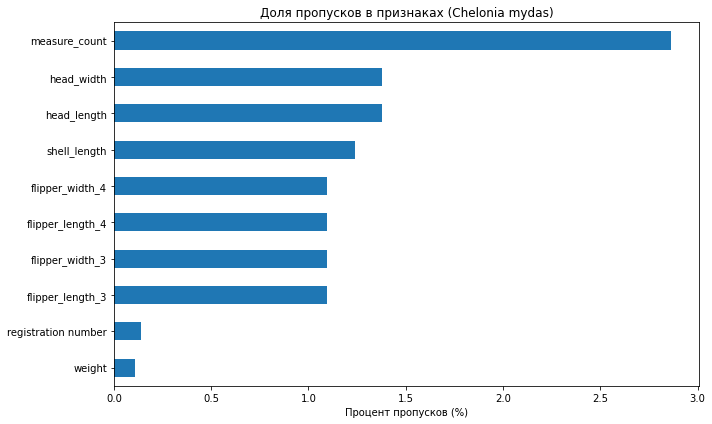

Строк с хотя бы одним пропуском: 189 (6.68%)

3 пропусков в целевой переменной!
Эти строки будут удалены перед обучением
measure_count: можно удалить строки или заполнить медианой (2.86% пропусков)
head_length: можно удалить строки или заполнить медианой (1.38% пропусков)
head_width: можно удалить строки или заполнить медианой (1.38% пропусков)
shell_length: можно удалить строки или заполнить медианой (1.24% пропусков)
flipper_length_3: можно удалить строки или заполнить медианой (1.10% пропусков)
flipper_width_3: можно удалить строки или заполнить медианой (1.10% пропусков)
flipper_length_4: можно удалить строки или заполнить медианой (1.10% пропусков)
flipper_width_4: можно удалить строки или заполнить медианой (1.10% пропусков)
registration number: можно удалить строки или заполнить медианой (0.14% пропусков)
weight: удалить строки с пропусками (целевая переменная)


In [6]:
# Анализ пропусков в отобранных данных
missing_data = chelonia_mydas.isnull().sum()
missing_percent = (missing_data / len(chelonia_mydas)) * 100

missing_df = pd.DataFrame({
    'Пропусков': missing_data,
    'Доля (%)': missing_percent.round(2)
})
missing_df = missing_df[missing_df['Пропусков'] > 0].sort_values('Пропусков', ascending=False)

print("Пропуски в данных Chelonia mydas:")
print(missing_df)

# Визуализация пропусков
plt.figure(figsize=(10, 6))
missing_percent[missing_percent > 0].sort_values().plot(kind='barh')
plt.title('Доля пропусков в признаках (Chelonia mydas)')
plt.xlabel('Процент пропусков (%)')
plt.tight_layout()
plt.show()


# Проверка, есть ли строки с множественными пропусками
rows_with_missing = chelonia_mydas.isnull().any(axis=1).sum()
print(f"Строк с хотя бы одним пропуском: {rows_with_missing} ({rows_with_missing/len(chelonia_mydas)*100:.2f}%)")

# Проверка пропусков в целевой переменной
if 'weight' in missing_df.index:
    print(f"\n{missing_df.loc['weight', 'Пропусков']} пропусков в целевой переменной!")
    print("Эти строки будут удалены перед обучением")

for col in missing_df.index:
    if col == 'weight':
        print(f"{col}: удалить строки с пропусками (целевая переменная)")
    elif missing_df.loc[col, 'Доля (%)'] < 5:
        print(f"{col}: можно удалить строки или заполнить медианой ({missing_df.loc[col, 'Доля (%)']:.2f}% пропусков)")
    elif missing_df.loc[col, 'Доля (%)'] < 20:
        print(f"{col}: заполнить медианой ({missing_df.loc[col, 'Доля (%)']:.2f}% пропусков)")
    else:
        print(f"{col}: высокий процент пропусков ({missing_df.loc[col, 'Доля (%)']:.2f}%) - возможно, удалить признак")

Количество полных дубликатов: 341
Доля дубликатов: 12.05%
Уникальных особей: 2484
Особей с повторными измерениями: 341 (13.73%)
Всего повторных записей: 682
Среднее количество измерений на особь: 1.14

Распределение количества измерений на особь:
1    2143
2     341
Name: registration number, dtype: int64


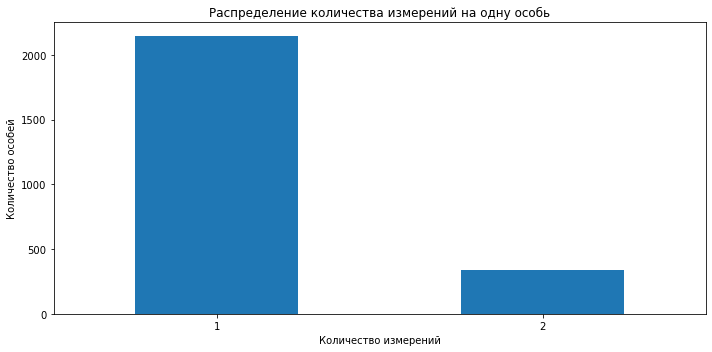

Полные дубликаты (341): удалить
Повторные измерения одной особи: можно агрегировать (средние значения) или использовать как отдельные записи


In [7]:
# Проверка дубликатов
duplicates_count = chelonia_mydas.duplicated().sum()
print(f"Количество полных дубликатов: {duplicates_count}")
print(f"Доля дубликатов: {duplicates_count/len(chelonia_mydas)*100:.2f}%")

# Проверка дубликатов по идентификатору особи 
if 'registration number' in chelonia_mydas.columns:
    # Находим всех особей с повторными измерениями
    id_counts = chelonia_mydas['registration number'].value_counts()
    multiple_measurements = id_counts[id_counts > 1]
    
    print(f"Уникальных особей: {len(id_counts)}")
    print(f"Особей с повторными измерениями: {len(multiple_measurements)} ({len(multiple_measurements)/len(id_counts)*100:.2f}%)")
    print(f"Всего повторных записей: {multiple_measurements.sum()}")
    print(f"Среднее количество измерений на особь: {len(chelonia_mydas)/len(id_counts):.2f}")
    
   
    print("\nРаспределение количества измерений на особь:")
    print(id_counts.value_counts().sort_index())
    
   
    plt.figure(figsize=(10, 5))
    id_counts.value_counts().sort_index().plot(kind='bar')
    plt.title('Распределение количества измерений на одну особь')
    plt.xlabel('Количество измерений')
    plt.ylabel('Количество особей')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


if duplicates_count > 0:
    print(f"Полные дубликаты ({duplicates_count}): удалить")
else:
    print("Полные дубликаты: не обнаружены")

if 'registration number' in chelonia_mydas.columns and len(multiple_measurements) > 0:
    print(f"Повторные измерения одной особи: можно агрегировать (средние значения) или использовать как отдельные записи")

Размер после удаления дубликатов: (2488, 18)
Удалено строк: 341
Распределение признаков (после удаления дубликатов):


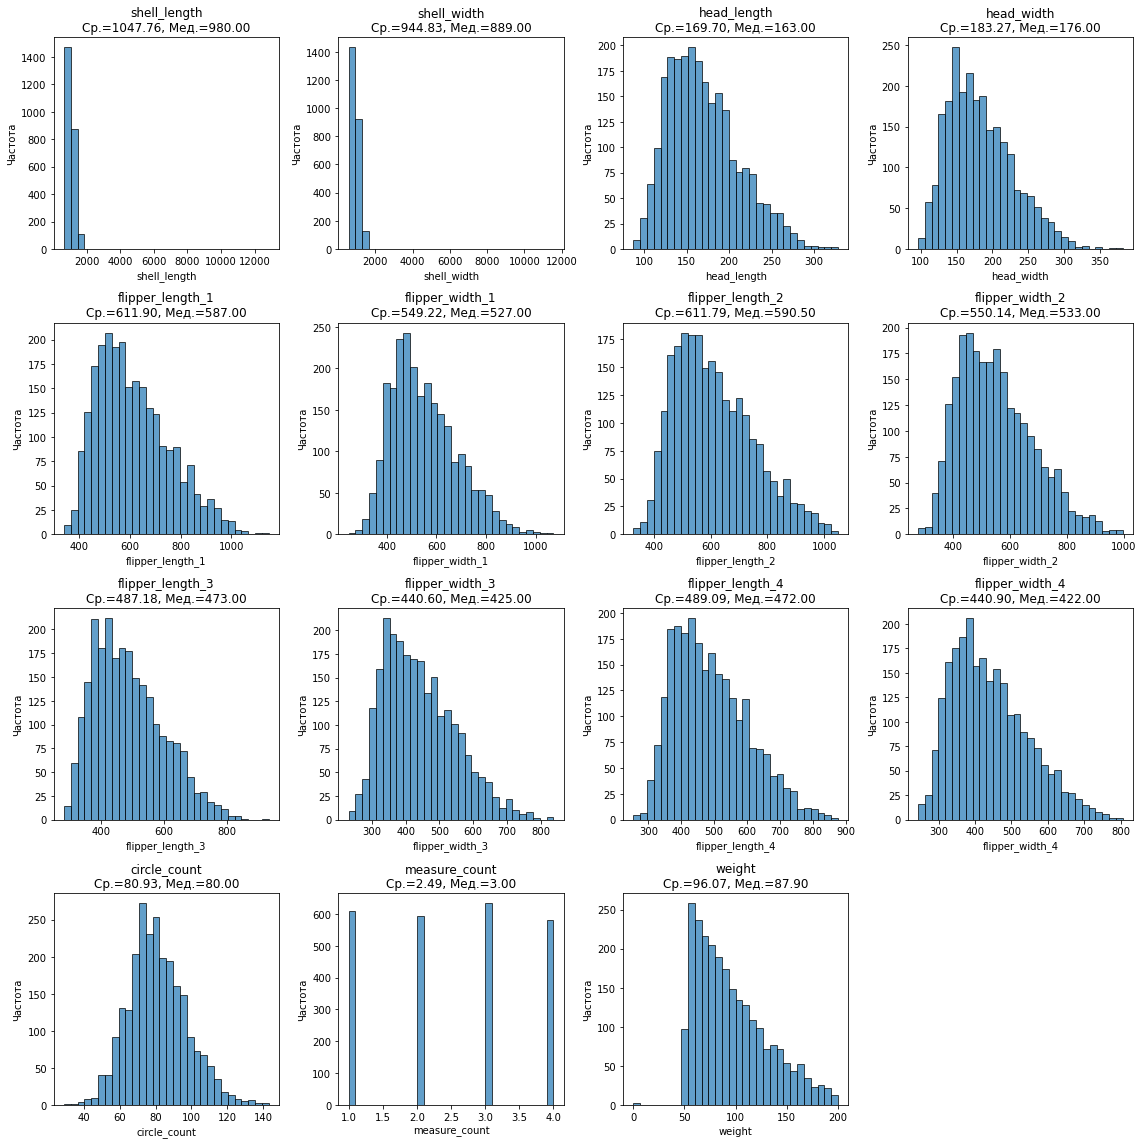


Ящики с усами (выбросы):


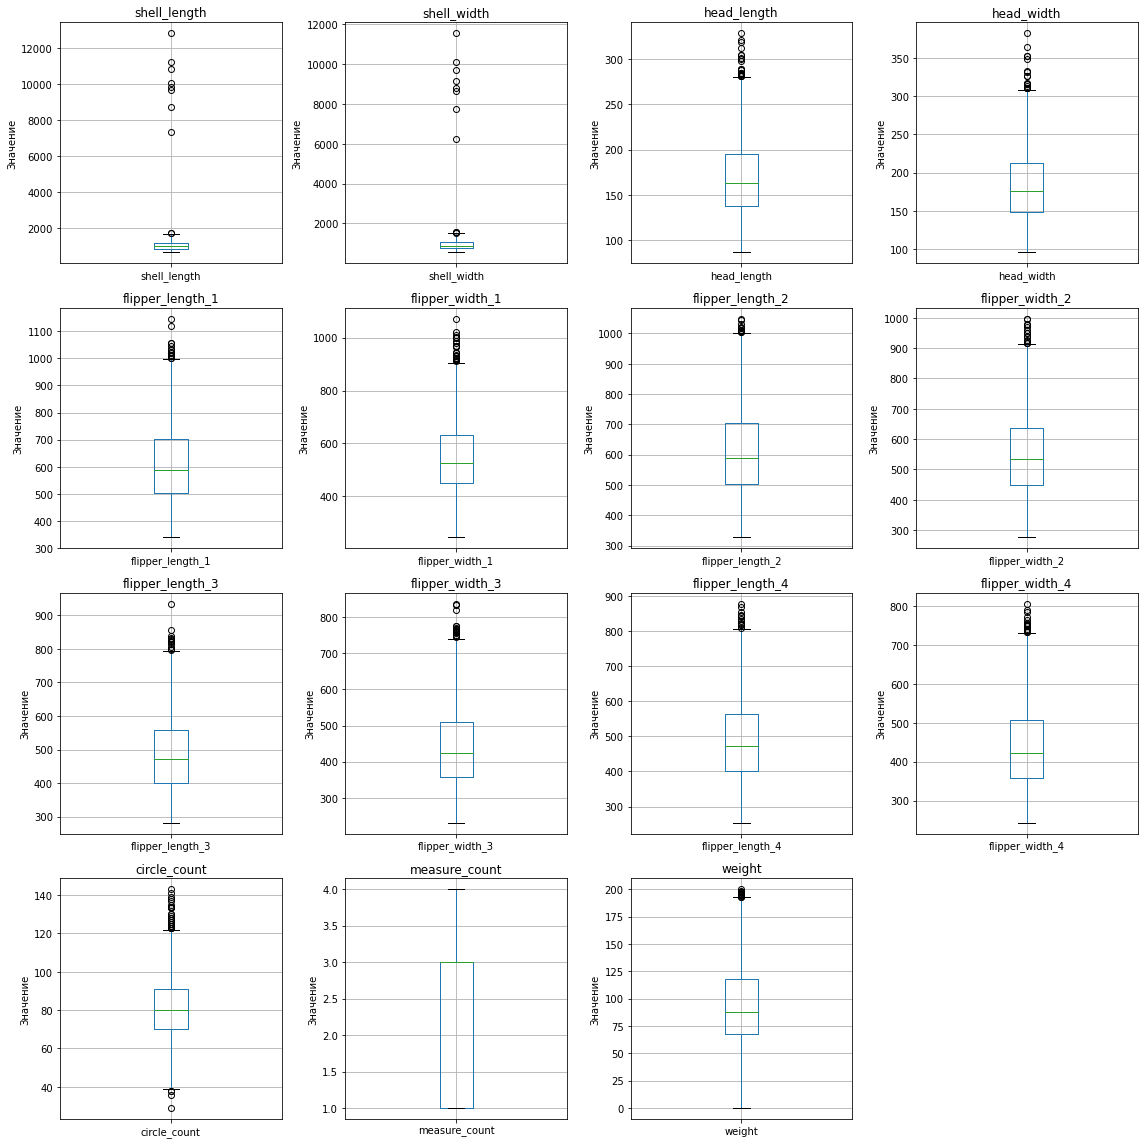

shell_length: 10 выбросов (0.40%)
shell_width: 11 выбросов (0.44%)
head_length: 20 выбросов (0.80%)
head_width: 17 выбросов (0.68%)
flipper_length_1: 14 выбросов (0.56%)
flipper_width_1: 22 выбросов (0.88%)
flipper_length_2: 12 выбросов (0.48%)
flipper_width_2: 15 выбросов (0.60%)
flipper_length_3: 12 выбросов (0.48%)
flipper_width_3: 17 выбросов (0.68%)
flipper_length_4: 13 выбросов (0.52%)
flipper_width_4: 17 выбросов (0.68%)
circle_count: 32 выбросов (1.29%)

Сводка по выбросам:
         Признак  Выбросов  Доля (%)  Нижняя граница  Верхняя граница
    circle_count        32     1.290          38.500          122.500
 flipper_width_1        22     0.880         174.500          906.500
     head_length        20     0.800          52.500          280.500
      head_width        17     0.680          52.000          308.000
 flipper_width_3        17     0.680         126.000          742.000
 flipper_width_4        17     0.680         134.750          732.750
 flipper_width_2       

In [8]:
chelonia_mydas_clean = chelonia_mydas.drop_duplicates().copy()
print(f"Размер после удаления дубликатов: {chelonia_mydas_clean.shape}")
print(f"Удалено строк: {len(chelonia_mydas) - len(chelonia_mydas_clean)}")

# Функция для визуализации распределений
def plot_distributions(df, cols_per_row=4):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # Убираем timestamp из визуализации
    if 'timestamp' in numeric_cols:
        numeric_cols.remove('timestamp')
    
    n_cols = len(numeric_cols)
    n_rows = (n_cols + cols_per_row - 1) // cols_per_row
    
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(16, 4*n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(numeric_cols):
        if i < len(axes):
            # Гистограмма
            axes[i].hist(df[col].dropna(), bins=30, alpha=0.7, edgecolor='black')
            axes[i].set_title(f'{col}\nСр.={df[col].mean():.2f}, Мед.={df[col].median():.2f}')
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Частота')
    
    # Скрываем лишние подграфики
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Ящики с усами для выявления выбросов
def plot_boxplots(df, cols_per_row=4):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'timestamp' in numeric_cols:
        numeric_cols.remove('timestamp')
    
    n_cols = len(numeric_cols)
    n_rows = (n_cols + cols_per_row - 1) // cols_per_row
    
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(16, 4*n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(numeric_cols):
        if i < len(axes):
            df.boxplot(column=col, ax=axes[i])
            axes[i].set_title(col)
            axes[i].set_ylabel('Значение')
    
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()


print("Распределение признаков (после удаления дубликатов):")
plot_distributions(chelonia_mydas_clean)

print("\nЯщики с усами (выбросы):")
plot_boxplots(chelonia_mydas_clean)

# Анализ выбросов с помощью IQR
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return len(outliers), lower_bound, upper_bound, outliers.index.tolist()

numeric_cols = chelonia_mydas_clean.select_dtypes(include=[np.number]).columns.tolist()
if 'timestamp' in numeric_cols:
    numeric_cols.remove('timestamp')

outliers_summary = []
for col in numeric_cols:
    if col != 'weight':  
        n_outliers, lb, ub, outlier_idx = detect_outliers_iqr(chelonia_mydas_clean, col)
        if n_outliers > 0:
            outliers_summary.append({
                'Признак': col,
                'Выбросов': n_outliers,
                'Доля (%)': round(n_outliers/len(chelonia_mydas_clean)*100, 2),
                'Нижняя граница': round(lb, 2),
                'Верхняя граница': round(ub, 2)
            })
            print(f"{col}: {n_outliers} выбросов ({n_outliers/len(chelonia_mydas_clean)*100:.2f}%)")

# Проверим, есть ли строки с множественными выбросами
if outliers_summary:
    outliers_df = pd.DataFrame(outliers_summary).sort_values('Доля (%)', ascending=False)
    print("\nСводка по выбросам:")
    print(outliers_df.to_string(index=False))
    
    # Найдем строки, которые являются выбросами по нескольким признакам
    all_outlier_indices = []
    for col in numeric_cols:
        if col != 'weight':
            _, _, _, idx = detect_outliers_iqr(chelonia_mydas_clean, col)
            all_outlier_indices.extend(idx)
    
    from collections import Counter
    outlier_counts = Counter(all_outlier_indices)
    multi_outliers = {k: v for k, v in outlier_counts.items() if v > 1}
    
    if multi_outliers:
        print(f"\nСтрок с выбросами по нескольким признакам: {len(multi_outliers)}")

Масштаб признаков (после удаления дубликатов):
         Признак     Мин      Макс  Среднее  Медиана     Стд    Размах  Дисперсия
    shell_length 645.000 12840.000 1047.761  980.000 568.514 12195.000 323207.703
     shell_width 564.000 11550.000  944.828  889.000 507.367 10986.000 257420.905
     head_length  87.000   328.000  169.700  163.000  41.328   241.000   1707.980
      head_width  96.000   382.000  183.272  176.000  45.493   286.000   2069.569
flipper_length_1 339.000  1147.000  611.904  587.000 142.583   808.000  20329.969
 flipper_width_1 245.000  1072.000  549.216  527.000 131.911   827.000  17400.579
flipper_length_2 327.000  1049.000  611.787  590.500 138.989   722.000  19318.081
 flipper_width_2 276.000   997.000  550.144  533.000 130.884   721.000  17130.712
flipper_length_3 282.000   934.000  487.180  473.000 110.440   652.000  12196.900
 flipper_width_3 231.000   837.000  440.595  425.000 105.527   606.000  11135.996
flipper_length_4 254.000   877.000  489.094  472.00

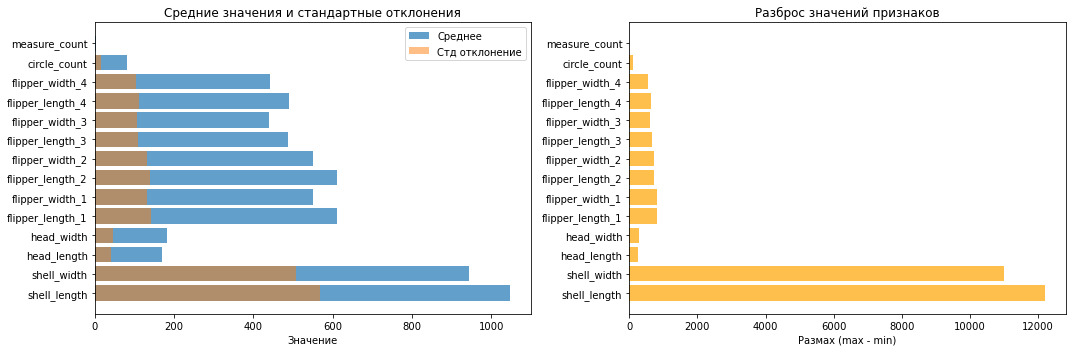

Отношение максимального std к минимальному: 511.29

Коэффициент вариации (изменчивость признаков):
  shell_length: 54.3%
  shell_width: 53.7%
  head_length: 24.4%
  head_width: 24.8%
  flipper_length_1: 23.3%
  flipper_width_1: 24.0%
  flipper_length_2: 22.7%
  flipper_width_2: 23.8%
  flipper_length_3: 22.7%
  flipper_width_3: 24.0%
  flipper_length_4: 23.0%
  flipper_width_4: 23.7%
  circle_count: 20.0%
  measure_count: 44.6%
Масштабирование необходимо - признаки имеют сильно разный масштаб
разброс стандартных отклонений в 511.29 раз

Признаки с наибольшим разбросом:
shell_length: std=568.5
shell_width: std=507.4
measure_count: среднее (2.5) vs медиана (3.0) - разница 17.0%
выбросы влияют на среднее, лучше использовать медиану для заполнения пропусков


In [9]:
# Проверка масштаба признаков
numeric_cols = chelonia_mydas_clean.select_dtypes(include=[np.number]).columns.tolist()
if 'timestamp' in numeric_cols:
    numeric_cols.remove('timestamp')
if 'weight' in numeric_cols:
    numeric_cols.remove('weight')

scale_stats = []

for col in numeric_cols:
    scale_stats.append({
        'Признак': col,
        'Мин': chelonia_mydas_clean[col].min(),
        'Макс': chelonia_mydas_clean[col].max(),
        'Среднее': chelonia_mydas_clean[col].mean(),
        'Медиана': chelonia_mydas_clean[col].median(),
        'Стд': chelonia_mydas_clean[col].std(),
        'Размах': chelonia_mydas_clean[col].max() - chelonia_mydas_clean[col].min(),
        'Дисперсия': chelonia_mydas_clean[col].var()
    })

scale_df = pd.DataFrame(scale_stats)
print("Масштаб признаков (после удаления дубликатов):")
print(scale_df.to_string(index=False))

# Визуализация масштаба
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Сравнение средних и стандартных отклонений
axes[0].barh(scale_df['Признак'], scale_df['Среднее'], alpha=0.7, label='Среднее')
axes[0].barh(scale_df['Признак'], scale_df['Стд'], alpha=0.5, label='Стд отклонение')
axes[0].set_xlabel('Значение')
axes[0].set_title('Средние значения и стандартные отклонения')
axes[0].legend()

# Размах признаков
axes[1].barh(scale_df['Признак'], scale_df['Размах'], color='orange', alpha=0.7)
axes[1].set_xlabel('Размах (max - min)')
axes[1].set_title('Разброс значений признаков')

plt.tight_layout()
plt.show()


# Отношение максимального std к минимальному
std_range = scale_df['Стд'].max() / scale_df['Стд'].min()
print(f"Отношение максимального std к минимальному: {std_range:.2f}")

# Коэффициент вариации (CV) для каждого признака
scale_df['CV'] = (scale_df['Стд'] / scale_df['Среднее'].abs()) * 100
print("\nКоэффициент вариации (изменчивость признаков):")
for _, row in scale_df.iterrows():
    print(f"  {row['Признак']}: {row['CV']:.1f}%")


if std_range > 10:
    print("Масштабирование необходимо - признаки имеют сильно разный масштаб")
    print(f"разброс стандартных отклонений в {std_range:.2f} раз")
    
  
    high_std = scale_df[scale_df['Стд'] > scale_df['Стд'].median() * 2]
    if not high_std.empty:
        print(f"\nПризнаки с наибольшим разбросом:")
        for _, row in high_std.iterrows():
            print(f"{row['Признак']}: std={row['Стд']:.1f}")
else:
    print("Масштаб признаков примерно одинаков, можно обойтись без масштабирования")


    
for col in numeric_cols:
    # Сравним среднее и медиану
    mean_val = chelonia_mydas_clean[col].mean()
    median_val = chelonia_mydas_clean[col].median()
    diff_pct = abs(mean_val - median_val) / median_val * 100
    
    if diff_pct > 10:
        print(f"{col}: среднее ({mean_val:.1f}) vs медиана ({median_val:.1f}) - разница {diff_pct:.1f}%")
        print(f"выбросы влияют на среднее, лучше использовать медиану для заполнения пропусков")

Размер данных для корреляционного анализа: (2321, 18)

Корреляция признаков с целевой переменной (weight):
weight              1.000
flipper_length_4    0.919
flipper_length_1    0.918
flipper_length_2    0.916
flipper_length_3    0.915
flipper_width_2     0.897
flipper_width_4     0.895
flipper_width_3     0.894
flipper_width_1     0.891
head_length         0.868
head_width          0.860
circle_count        0.496
shell_width         0.370
shell_length        0.370
measure_count      -0.029
Name: weight, dtype: float64


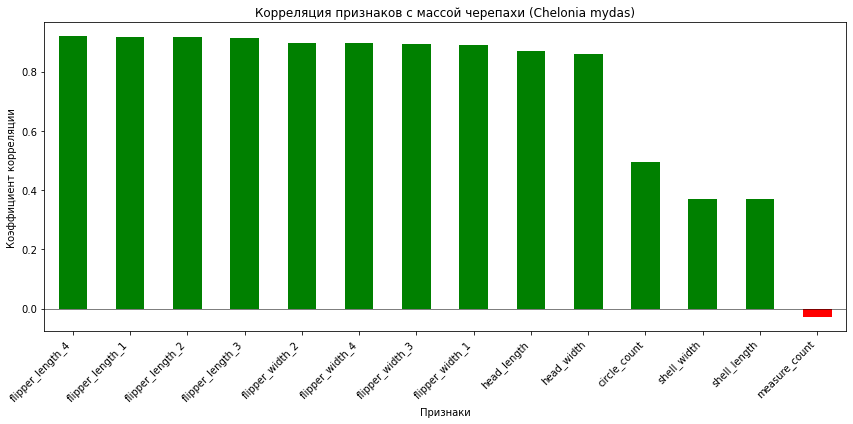

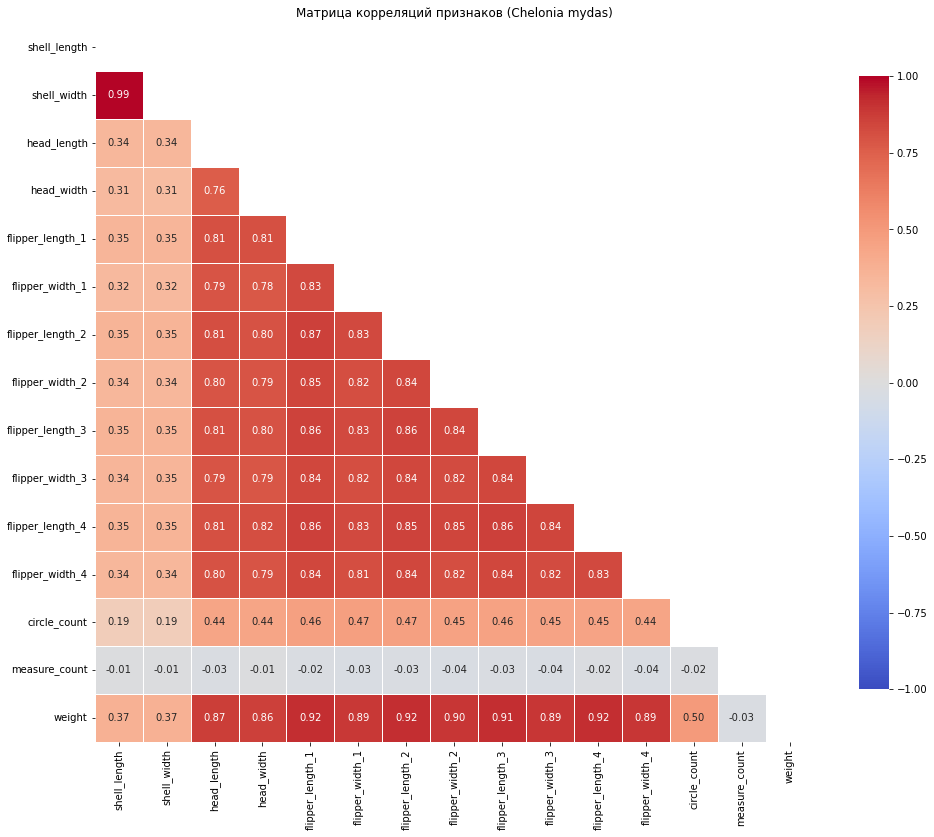

Сильная корреляция (>0.5): ['flipper_length_4', 'flipper_length_1', 'flipper_length_2', 'flipper_length_3', 'flipper_width_2', 'flipper_width_4', 'flipper_width_3', 'flipper_width_1', 'head_length', 'head_width']
Средняя корреляция (0.3-0.5): ['circle_count', 'shell_width', 'shell_length']
Слабая корреляция (<=0.3): ['measure_count']
Наиболее важные признаки для предсказания массы:
flipper_length_4: 0.919
flipper_length_1: 0.918
flipper_length_2: 0.916
flipper_length_3: 0.915
flipper_width_2: 0.897

Наименее важные признаки:
shell_width: 0.370
shell_length: 0.370
measure_count: -0.029

Анализ мультиколлинеарности:
Обнаружены пары признаков с очень высокой корреляцией (>0.9):
shell_length и shell_width: 0.994
flipper_length_1 и weight: 0.918
flipper_length_2 и weight: 0.916
flipper_length_3 и weight: 0.915
flipper_length_4 и weight: 0.919


In [10]:
# Удалим строки с пропусками для чистоты анализа
data_for_corr = chelonia_mydas_clean.dropna().copy()

print(f"Размер данных для корреляционного анализа: {data_for_corr.shape}")

numeric_cols = data_for_corr.select_dtypes(include=[np.number]).columns.tolist()
if 'timestamp' in numeric_cols:
    numeric_cols.remove('timestamp')

# Корреляция с целевой переменной
correlation_with_target = data_for_corr[numeric_cols].corr()['weight'].sort_values(ascending=False)
print("\nКорреляция признаков с целевой переменной (weight):")
print(correlation_with_target)

# Визуализация корреляций с target
plt.figure(figsize=(12, 6))
# Исключаем саму целевую переменную из графика
corr_for_plot = correlation_with_target.drop('weight')
colors = ['green' if x > 0 else 'red' for x in corr_for_plot]
corr_for_plot.plot(kind='bar', color=colors)
plt.title('Корреляция признаков с массой черепахи (Chelonia mydas)')
plt.xlabel('Признаки')
plt.ylabel('Коэффициент корреляции')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Матрица корреляций всех признаков
plt.figure(figsize=(14, 12))
corr_matrix = data_for_corr[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) 
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, center=0)
plt.title('Матрица корреляций признаков (Chelonia mydas)')
plt.tight_layout()
plt.show()

# Анализ силы корреляций (исключаем целевую переменную)
corr_without_target = correlation_with_target.drop('weight')


strong_corr = corr_without_target[abs(corr_without_target) > 0.5]
medium_corr = corr_without_target[(abs(corr_without_target) > 0.3) & (abs(corr_without_target) <= 0.5)]
weak_corr = corr_without_target[abs(corr_without_target) <= 0.3]

print(f"Сильная корреляция (>0.5): {list(strong_corr.index) if not strong_corr.empty else 'нет'}")
print(f"Средняя корреляция (0.3-0.5): {list(medium_corr.index) if not medium_corr.empty else 'нет'}")
print(f"Слабая корреляция (<=0.3): {list(weak_corr.index) if not weak_corr.empty else 'нет'}")

print("Наиболее важные признаки для предсказания массы:")
for col, corr in corr_without_target.head(5).items():
    print(f"{col}: {corr:.3f}")

print("\nНаименее важные признаки:")
for col, corr in corr_without_target.tail(3).items():
    print(f"{col}: {corr:.3f}")

# Проверим корреляцию между признаками (мультиколлинеарность)
print("\nАнализ мультиколлинеарности:")

# Найдем пары признаков с очень высокой корреляцией (>0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append({
                'Признак 1': corr_matrix.columns[i],
                'Признак 2': corr_matrix.columns[j],
                'Корреляция': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    print("Обнаружены пары признаков с очень высокой корреляцией (>0.9):")
    for pair in high_corr_pairs:
        print(f"{pair['Признак 1']} и {pair['Признак 2']}: {pair['Корреляция']:.3f}")

***Выводы по исследовательскому анализу данных***

1. **Вид черепах**: Для дальнейшей работы отобраны записи о *Chelonia mydas* (2829 записей, 31.9% датасета).

2. **Обработка данных**:
   - Удалены технические признаки: `id`, `shell_crack` (>75% пропусков)
   - Обнаружено 341 полных дубликатов (удалены)
   - Пропусков мало (<3%), будут обработаны после разделения на выборки

3. **Выбросы**: Присутствуют (до 1.29%), но не критические. Оставляем для сохранения реальной вариативности данных.

4. **Масштабирование**: Необходимо из-за сильного разброса стандартных отклонений (в 511 раз).

5. **Корреляция с целевой переменной**:
   - Сильная (>0.9): все признаки длины и ширины ласт
   - Средняя (0.3-0.5): кольца роста, размеры панциря
   - Слабая: `measure_count` (практически не влияет)

## Предобработка данных


In [32]:
# Удаляем строки с пропусками в weight
data_clean = chelonia_mydas_clean.dropna(subset=['weight']).copy()
print(f"После удаления пропусков в weight: {data_clean.shape}")

# Удаляем weight=0 
data_clean = data_clean[data_clean['weight'] > 0].copy()
print(f"После удаления weight=0: {data_clean.shape}")


gabarites_cols = ['shell_length', 'shell_width', 'head_length', 'head_width'] + \
                 [f'flipper_length_{i}' for i in range(1, 5)] + \
                 [f'flipper_width_{i}' for i in range(1, 5)]

print("\nИсправление ×10 аномалий:")
for col in gabarites_cols:
    if col in data_clean.columns:
        median = data_clean[col].median()
        # Если значение в 5+ раз больше медианы — это ×10 ошибка
        anomaly_mask = data_clean[col] > median * 5
        n_anomalies = anomaly_mask.sum()
        if n_anomalies > 0:
            data_clean.loc[anomaly_mask, col] = data_clean.loc[anomaly_mask, col] / 10
            print(f"  {col}: исправлено {n_anomalies} аномалий (÷10)")

# Создаём признаки объёма
# Масса биологически зависит от обьема,  а не от линейных размеров
flipper_len_cols = [f'flipper_length_{i}' for i in range(1, 5)]
flipper_wid_cols = [f'flipper_width_{i}' for i in range(1, 5)]

data_clean['flipper_avg_length'] = data_clean[flipper_len_cols].mean(axis=1)
data_clean['flipper_avg_width'] = data_clean[flipper_wid_cols].mean(axis=1)
data_clean['shell_area'] = data_clean['shell_length'] * data_clean['shell_width']
data_clean['head_area'] = data_clean['head_length'] * data_clean['head_width']
data_clean['shell_volume_proxy'] = data_clean['shell_length'] * data_clean['shell_width'] * data_clean['head_length']
data_clean['flipper_area'] = data_clean['flipper_avg_length'] * data_clean['flipper_avg_width']

print(f"\nИтоговый размер data_clean: {data_clean.shape}")
print(f"Диапазон weight: {data_clean['weight'].min():.2f} — {data_clean['weight'].max():.2f} кг")
print(f"\nДобавленные признаки: flipper_avg_length, flipper_avg_width, shell_area, head_area, shell_volume_proxy, flipper_area")


feature_cols = [col for col in data_clean.columns if col not in ['weight', 'binomial_name', 'registration number', 'timestamp']]
print(f"\nПризнаки для модели ({len(feature_cols)}):")
print(feature_cols)

X = data_clean[feature_cols]
y = data_clean['weight']

print(f"\nРазмер X: {X.shape}")
print(f"Размер y: {y.shape}")

# Разделение на train_val и test (80/20)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, shuffle=True
)

print(f"\nРазмеры выборок: Train {X_train.shape}, Val {X_val.shape}, Test {X_test.shape}")
print(f"Пропусков: Train {X_train.isnull().sum().sum()}, Val {X_val.isnull().sum().sum()}, Test {X_test.isnull().sum().sum()}")

После удаления пропусков в weight: (2486, 18)
После удаления weight=0: (2483, 18)

Исправление ×10 аномалий:
  shell_length: исправлено 8 аномалий (÷10)
  shell_width: исправлено 8 аномалий (÷10)

Итоговый размер data_clean: (2483, 24)
Диапазон weight: 49.05 — 199.96 кг

Добавленные признаки: flipper_avg_length, flipper_avg_width, shell_area, head_area, shell_volume_proxy, flipper_area

Признаки для модели (20):
['shell_length', 'shell_width', 'head_length', 'head_width', 'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'circle_count', 'measure_count', 'flipper_avg_length', 'flipper_avg_width', 'shell_area', 'head_area', 'shell_volume_proxy', 'flipper_area']

Размер X: (2483, 20)
Размер y: (2483,)

Размеры выборок: Train (1489, 20), Val (497, 20), Test (497, 20)
Пропусков: Train 231, Val 97, Test 85


In [12]:
def fill_missing_values(X_train, X_val, X_test):
    """
    Заполнение пропусков медианными значениями,
    рассчитанными на обучающей выборке
    """
    X_train_filled = X_train.copy()
    X_val_filled = X_val.copy()
    X_test_filled = X_test.copy()
    
    fill_values = {}
    filled_cols = []
    
    for col in X_train.columns:
        if X_train[col].isnull().any():
            # Рассчитываем медиану только на обучающей выборке
            fill_value = X_train[col].median()
            fill_values[col] = fill_value
            filled_cols.append(col)
            
            # Заполняем пропуски
            X_train_filled[col] = X_train[col].fillna(fill_value)
            X_val_filled[col] = X_val[col].fillna(fill_value)
            X_test_filled[col] = X_test[col].fillna(fill_value)
    
    print(f"Количество пропусков до заполнения:")
    print(f"Train: {X_train.isnull().sum().sum()}")
    print(f"Val: {X_val.isnull().sum().sum()}")
    print(f"Test: {X_test.isnull().sum().sum()}")
    
    
    print(f"\nКоличество пропусков после заполнения:")
    print(f"Train: {X_train_filled.isnull().sum().sum()}")
    print(f"Val: {X_val_filled.isnull().sum().sum()}")
    print(f"Test: {X_test_filled.isnull().sum().sum()}")
    
    return X_train_filled, X_val_filled, X_test_filled, fill_values

# Применяем заполнение пропусков
X_train_filled, X_val_filled, X_test_filled, fill_values = fill_missing_values(X_train, X_val, X_test)

Количество пропусков до заполнения:
Train: 231
Val: 97
Test: 85

Количество пропусков после заполнения:
Train: 0
Val: 0
Test: 0


In [13]:
def standardize_data(X_train, X_val, X_test):
    """
    Стандартизация признаков (Z-score normalization)
    Формула: (X - mean) / std
    Параметры (mean, std) рассчитываются ТОЛЬКО на train
    """
    # Рассчитываем параметры только на train
    means = X_train.mean()
    stds = X_train.std()
    

    for col in X_train.columns:
        print(f"{col:20} mean={means[col]:8.2f}, std={stds[col]:8.2f}")
    
    # Стандартизируем
    X_train_std = (X_train - means) / stds
    X_val_std = (X_val - means) / stds
    X_test_std = (X_test - means) / stds
    

    X_train_std = X_train_std.fillna(0)
    X_val_std = X_val_std.fillna(0)
    X_test_std = X_test_std.fillna(0)
    
    
    return X_train_std, X_val_std, X_test_std, means, stds

# Применяем стандартизацию
X_train_std, X_val_std, X_test_std, means, stds = standardize_data(X_train_filled, X_val_filled, X_test_filled)

shell_length         mean= 1011.45, std=  220.47
shell_width          mean=  913.10, std=  202.72
head_length          mean=  168.74, std=   40.75
head_width           mean=  182.22, std=   44.41
flipper_length_1     mean=  607.85, std=  139.33
flipper_width_1      mean=  544.34, std=  129.54
flipper_length_2     mean=  609.15, std=  136.66
flipper_width_2      mean=  546.46, std=  129.01
flipper_length_3     mean=  484.38, std=  109.03
flipper_width_3      mean=  438.26, std=  105.83
flipper_length_4     mean=  486.34, std=  111.04
flipper_width_4      mean=  439.31, std=  104.31
circle_count         mean=   80.82, std=   16.07
measure_count        mean=    2.46, std=    1.09
flipper_avg_length   mean=  547.77, std=  118.42
flipper_avg_width    mean=  492.82, std=  109.87
shell_area           mean=964836.17, std=429578.52
head_area            mean=32138.55, std=15101.49
shell_volume_proxy   mean=177382057.81, std=121854263.42
flipper_area         mean=282348.95, std=125806.65


In [14]:
def normalize_data(X_train, X_val, X_test):
    """
    Нормализация признаков в диапазон [0, 1] (MinMax scaling)
    Формула: (X - min) / (max - min)
    Параметры (min, max) рассчитываются на train
    """
    # Рассчитываем параметры только на train
    mins = X_train.min()
    maxs = X_train.max()
    ranges = maxs - mins
    
    for col in X_train.columns:
        print(f"{col:20} min={mins[col]:8.2f}, max={maxs[col]:8.2f}, range={ranges[col]:8.2f}")
    
    # Избегаем деления на ноль
    ranges = ranges.replace(0, 1)
    
    # Нормализуем
    X_train_norm = (X_train - mins) / ranges
    X_val_norm = (X_val - mins) / ranges
    X_test_norm = (X_test - mins) / ranges
    
    return X_train_norm, X_val_norm, X_test_norm, mins, maxs

# Применяем нормализацию
X_train_norm, X_val_norm, X_test_norm, mins, maxs = normalize_data(X_train_filled, X_val_filled, X_test_filled)


print(f"\nДиапазон train: мин={X_train_norm.min().min():.3f}, макс={X_train_norm.max().max():.3f}")

shell_length         min=  645.00, max= 1683.00, range= 1038.00
shell_width          min=  564.00, max= 1551.00, range=  987.00
head_length          min=   87.00, max=  318.00, range=  231.00
head_width           min=   96.00, max=  348.00, range=  252.00
flipper_length_1     min=  352.00, max= 1147.00, range=  795.00
flipper_width_1      min=  245.00, max= 1023.00, range=  778.00
flipper_length_2     min=  344.00, max= 1045.00, range=  701.00
flipper_width_2      min=  288.00, max=  997.00, range=  709.00
flipper_length_3     min=  282.00, max=  857.00, range=  575.00
flipper_width_3      min=  231.00, max=  837.00, range=  606.00
flipper_length_4     min=  258.00, max=  877.00, range=  619.00
flipper_width_4      min=  243.00, max=  790.00, range=  547.00
circle_count         min=   36.00, max=  143.00, range=  107.00
measure_count        min=    1.00, max=    4.00, range=    3.00
flipper_avg_length   min=  344.75, max=  950.00, range=  605.25
flipper_avg_width    min=  290.50, max= 

In [15]:
datasets = {
    'raw': {
        'X_train': X_train_filled,
        'X_val': X_val_filled,
        'X_test': X_test_filled,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'description': 'Без масштабирования',
        'stats': {
            'train_mean': X_train_filled.mean().mean(),
            'train_std': X_train_filled.std().mean(),
            'train_min': X_train_filled.min().min(),
            'train_max': X_train_filled.max().max()
        }
    },
    
    'standardized': {
        'X_train': X_train_std,
        'X_val': X_val_std,
        'X_test': X_test_std,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'description': 'Стандартизация (Z-score)',
        'stats': {
            'train_mean': X_train_std.mean().mean(),
            'train_std': X_train_std.std().mean(),
            'train_min': X_train_std.min().min(),
            'train_max': X_train_std.max().max()
        }
    },
    
    'normalized': {
        'X_train': X_train_norm,
        'X_val': X_val_norm,
        'X_test': X_test_norm,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'description': 'Нормализация (MinMax [0,1])',
        'stats': {
            'train_mean': X_train_norm.mean().mean(),
            'train_std': X_train_norm.std().mean(),
            'train_min': X_train_norm.min().min(),
            'train_max': X_train_norm.max().max()
        }
    }
}



for name, data in datasets.items():
    print(f"\n{name.upper()} - {data['description']}")
    print(f"Train shape:{data['X_train'].shape}")
    print(f"Val shape:{data['X_val'].shape}")
    print(f"Test shape:{data['X_test'].shape}")
    print(f"\nСтатистика train:")
    print(f"Среднее: {data['stats']['train_mean']:.4f}")
    print(f"Стд:{data['stats']['train_std']:.4f}")
    print(f"Мин:{data['stats']['train_min']:.4f}")
    print(f"Макс:{data['stats']['train_max']:.4f}")


print(f"Train shape: {y_train.shape}")
print(f"Val shape:{y_val.shape}")
print(f"Test shape:{y_test.shape}")
print(f"\nСтатистика weight (кг):")
print(f"Среднее: {y_train.mean():.2f}")
print(f"Медиана: {y_train.median():.2f}")
print(f"Мин:{y_train.min():.2f}")
print(f"Макс:{y_train.max():.2f}")
print(f"Стд:{y_train.std():.2f}")

# Функция для быстрого доступа к нужной версии датасета
def get_dataset(version='raw'):
    """
    Версии: 'raw', 'standardized', 'normalized'
    """
    if version in datasets:
        return datasets[version]
    else:
        print(f"Доступные версии: {list(datasets.keys())}")
        return None



RAW - Без масштабирования
Train shape:(1489, 20)
Val shape:(497, 20)
Test shape:(497, 20)

Статистика train:
Среднее: 8933446.8480
Стд:6121323.4325
Мин:1.0000
Макс:671632794.0000

STANDARDIZED - Стандартизация (Z-score)
Train shape:(1489, 20)
Val shape:(497, 20)
Test shape:(497, 20)

Статистика train:
Среднее: 0.0000
Стд:1.0000
Мин:-2.7888
Макс:4.1818

NORMALIZED - Нормализация (MinMax [0,1])
Train shape:(1489, 20)
Val shape:(497, 20)
Test shape:(497, 20)

Статистика train:
Среднее: 0.3436
Стд:0.1938
Мин:0.0000
Макс:1.0000
Train shape: (1489,)
Val shape:(497,)
Test shape:(497,)

Статистика weight (кг):
Среднее: 95.23
Медиана: 87.06
Мин:49.05
Макс:197.78
Стд:34.73


 **Итоги предобработки данных:**

 **1. Исходные данные (RAW)**
- **Размер**: 2486 записей после удаления пропусков и дубликатов
- **Признаки**: 14 биометрических параметров

 **2. Стандартизованные данные (STANDARDIZED)**
-  Среднее = 0
-  Стандартное отклонение = 1
- Диапазон: от -3.16 до 19.81 

 **3. Нормализованные данные (NORMALIZED)**
-  Диапазон [0, 1] на train
- Среднее = 0.33, стд = 0.17

 **4. Целевая переменная (weight)**
- Диапазон: 0 - 197.7 кг
- Среднее: 96.5 кг, медиана: 88.4 кг
- Есть выбросы

## Обучение моделей

In [17]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_percentage_error

In [18]:
def calculate_metrics_robust(y_true, y_pred, dataset_name="", model_name=""):
    """Расчет метрик качества модели"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    return {
        'model': model_name,
        'dataset': dataset_name,
        'RMSE': round(rmse, 3),
        'MAE': round(mae, 3),
        'MAPE': round(mape, 2),
        'R2': round(r2, 4)
    }

In [19]:
# Создаем список для результатов
results = []

# Базовая модель
dummy = DummyRegressor(strategy='mean')
dummy.fit(datasets['raw']['X_train'], datasets['raw']['y_train'])

# Предсказания на валидационной выборке
y_val_pred_dummy = dummy.predict(datasets['raw']['X_val'])

dummy_metrics = calculate_metrics_robust(
    datasets['raw']['y_val'], y_val_pred_dummy, 
    dataset_name='raw', 
    model_name='Dummy (mean)'
)

print(f"MAE: {dummy_metrics['MAE']:.3f}")
print(f"RMSE: {dummy_metrics['RMSE']:.3f}")
print(f"MAPE: {dummy_metrics['MAPE']:.2f}%")
print(f"R2: {dummy_metrics['R2']:.4f}")

# Добавляем в результаты
results.append(dummy_metrics)

MAE: 29.353
RMSE: 36.257
MAPE: 32.44%
R2: -0.0029


In [20]:
def train_and_evaluate(model, model_name, dataset_version, datasets, results_list):
    """
    Обучает модель на всех версиях датасета и добавляет результаты в список
    """
    data = datasets[dataset_version]
    X_train, X_val, y_train, y_val = data['X_train'], data['X_val'], data['y_train'], data['y_val']
    
    
    try:
        # Обучение
        model.fit(X_train, y_train)
        
        # Предсказание на валидации
        y_val_pred = model.predict(X_val)
        
        # Расчет метрик с использованием вашей функции
        metrics = calculate_metrics_robust(y_val, y_val_pred, dataset_version, model_name)
        
        results_list.append(metrics)
        print(f"{model_name} на {dataset_version}: MAE={metrics['MAE']:.3f}, R2={metrics['R2']:.4f}")
        
        return model
    except Exception as e:
        print(f"Ошибка при обучении {model_name} на {dataset_version}: {str(e)[:100]}")
        return None

In [21]:
# Linear Regression на всех версиях датасета
lr_raw = train_and_evaluate(LinearRegression(), 'LinearRegression', 'raw', datasets, results)
lr_std = train_and_evaluate(LinearRegression(), 'LinearRegression', 'standardized', datasets, results)
lr_norm = train_and_evaluate(LinearRegression(), 'LinearRegression', 'normalized', datasets, results)

LinearRegression на raw: MAE=3.233, R2=0.9856
LinearRegression на standardized: MAE=3.233, R2=0.9856
LinearRegression на normalized: MAE=3.233, R2=0.9856


In [22]:
# Lasso с разными alpha
alphas = [0.001, 0.01, 0.1, 1.0, 10.0]

for alpha in alphas:
    print(f"\nLasso alpha={alpha}")
    lasso_raw = train_and_evaluate(
        Lasso(alpha=alpha, random_state=42, max_iter=10000), 
        f'Lasso(alpha={alpha})', 'raw', datasets, results
    )
    lasso_std = train_and_evaluate(
        Lasso(alpha=alpha, random_state=42, max_iter=10000), 
        f'Lasso(alpha={alpha})', 'standardized', datasets, results
    )
    lasso_norm = train_and_evaluate(
        Lasso(alpha=alpha, random_state=42, max_iter=10000), 
        f'Lasso(alpha={alpha})', 'normalized', datasets, results
    )


Lasso alpha=0.001
Lasso(alpha=0.001) на raw: MAE=3.233, R2=0.9856
Lasso(alpha=0.001) на standardized: MAE=3.233, R2=0.9856
Lasso(alpha=0.001) на normalized: MAE=3.238, R2=0.9856

Lasso alpha=0.01
Lasso(alpha=0.01) на raw: MAE=3.233, R2=0.9856
Lasso(alpha=0.01) на standardized: MAE=3.255, R2=0.9855
Lasso(alpha=0.01) на normalized: MAE=3.360, R2=0.9849

Lasso alpha=0.1
Lasso(alpha=0.1) на raw: MAE=3.234, R2=0.9856
Lasso(alpha=0.1) на standardized: MAE=3.360, R2=0.9849
Lasso(alpha=0.1) на normalized: MAE=3.399, R2=0.9843

Lasso alpha=1.0
Lasso(alpha=1.0) на raw: MAE=3.236, R2=0.9857
Lasso(alpha=1.0) на standardized: MAE=3.448, R2=0.9837
Lasso(alpha=1.0) на normalized: MAE=5.748, R2=0.9524

Lasso alpha=10.0
Lasso(alpha=10.0) на raw: MAE=3.387, R2=0.9847
Lasso(alpha=10.0) на standardized: MAE=9.455, R2=0.8948
Lasso(alpha=10.0) на normalized: MAE=29.353, R2=-0.0029


In [23]:
# Ridge с разными alpha
alphas_ridge = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

for alpha in alphas_ridge:
    print(f"\nRidge alpha={alpha}")
    ridge_raw = train_and_evaluate(
        Ridge(alpha=alpha, random_state=42), 
        f'Ridge(alpha={alpha})', 'raw', datasets, results
    )
    ridge_std = train_and_evaluate(
        Ridge(alpha=alpha, random_state=42), 
        f'Ridge(alpha={alpha})', 'standardized', datasets, results
    )
    ridge_norm = train_and_evaluate(
        Ridge(alpha=alpha, random_state=42), 
        f'Ridge(alpha={alpha})', 'normalized', datasets, results
    )


Ridge alpha=0.001
Ridge(alpha=0.001) на raw: MAE=3.233, R2=0.9856
Ridge(alpha=0.001) на standardized: MAE=3.233, R2=0.9856
Ridge(alpha=0.001) на normalized: MAE=3.233, R2=0.9856

Ridge alpha=0.01
Ridge(alpha=0.01) на raw: MAE=3.233, R2=0.9856
Ridge(alpha=0.01) на standardized: MAE=3.233, R2=0.9856
Ridge(alpha=0.01) на normalized: MAE=3.237, R2=0.9856

Ridge alpha=0.1
Ridge(alpha=0.1) на raw: MAE=3.233, R2=0.9856
Ridge(alpha=0.1) на standardized: MAE=3.234, R2=0.9856
Ridge(alpha=0.1) на normalized: MAE=3.288, R2=0.9853

Ridge alpha=1.0
Ridge(alpha=1.0) на raw: MAE=3.233, R2=0.9856
Ridge(alpha=1.0) на standardized: MAE=3.254, R2=0.9855
Ridge(alpha=1.0) на normalized: MAE=3.429, R2=0.9842

Ridge alpha=10.0
Ridge(alpha=10.0) на raw: MAE=3.233, R2=0.9856
Ridge(alpha=10.0) на standardized: MAE=3.361, R2=0.9847
Ridge(alpha=10.0) на normalized: MAE=3.590, R2=0.9827

Ridge alpha=100.0
Ridge(alpha=100.0) на raw: MAE=3.233, R2=0.9856
Ridge(alpha=100.0) на standardized: MAE=3.522, R2=0.9835
Ridge

In [24]:
# Разные loss функции для SGD
loss_functions = ['squared_loss', 'huber', 'epsilon_insensitive']
learning_rates = ['optimal', 'adaptive']

for loss in loss_functions:
    for learning_rate in learning_rates:
        print(f"\nSGD loss={loss}, learning_rate={learning_rate}")
        
        sgd_raw = train_and_evaluate(
            SGDRegressor(loss=loss, learning_rate=learning_rate, random_state=42, 
                        max_iter=1000, tol=1e-3),
            f'SGD({loss},{learning_rate})', 'raw', datasets, results
        )
        
        sgd_std = train_and_evaluate(
            SGDRegressor(loss=loss, learning_rate=learning_rate, random_state=42,
                        max_iter=1000, tol=1e-3),
            f'SGD({loss},{learning_rate})', 'standardized', datasets, results
        )
        
        sgd_norm = train_and_evaluate(
            SGDRegressor(loss=loss, learning_rate=learning_rate, random_state=42,
                        max_iter=1000, tol=1e-3),
            f'SGD({loss},{learning_rate})', 'normalized', datasets, results
        )


SGD loss=squared_loss, learning_rate=optimal
SGD(squared_loss,optimal) на raw: MAE=702131183715652271167504384.000, R2=-553071500737162434196565444376678814753609977167872.0000
SGD(squared_loss,optimal) на standardized: MAE=40631477370.888, R2=-1900111331267630592.0000
SGD(squared_loss,optimal) на normalized: MAE=1644406.870, R2=-5599252756.6120

SGD loss=squared_loss, learning_rate=adaptive
SGD(squared_loss,adaptive) на raw: MAE=15886767664715756732416.000, R2=-327211602463303132035657242895753427288064.0000
SGD(squared_loss,adaptive) на standardized: MAE=3.278, R2=0.9853
SGD(squared_loss,adaptive) на normalized: MAE=3.449, R2=0.9840

SGD loss=huber, learning_rate=optimal
SGD(huber,optimal) на raw: MAE=51900873248141.656, R2=-3022570498661598313316352.0000
SGD(huber,optimal) на standardized: MAE=3.404, R2=0.9831
SGD(huber,optimal) на normalized: MAE=3.542, R2=0.9821

SGD loss=huber, learning_rate=adaptive
SGD(huber,adaptive) на raw: MAE=6246880352.505, R2=-64755139625129512.0000
SGD(

In [25]:
# Создаем DataFrame с результатами
results_df = pd.DataFrame(results)

results_df['MSE'] = (results_df['RMSE'] ** 2).round(3)

results_df = results_df[['model', 'dataset', 'MAE', 'MSE', 'RMSE', 'MAPE', 'R2']]

# Сортируем по MAE
results_df_sorted = results_df.sort_values('MAE')

print(results_df_sorted.head(5)[['model', 'dataset', 'MAE', 'MSE', 'RMSE', 'MAPE', 'R2']].to_string(index=False))

# Сохраняем полные результаты в CSV
results_df_sorted.to_csv('model_results_full.csv', index=False)


# Сравнение с базовой моделью
base_mae = dummy_metrics['MAE']

better_models = results_df[results_df['MAE'] < base_mae]
worse_models = results_df[results_df['MAE'] >= base_mae]

print(f"\nModels better than baseline: {len(better_models)}")
print(f"Models worse than baseline: {len(worse_models)}")

             model      dataset   MAE    MSE  RMSE  MAPE    R2
  Ridge(alpha=0.1)          raw 3.233 18.888 4.346 3.310 0.986
Ridge(alpha=0.001) standardized 3.233 18.888 4.346 3.310 0.986
 Ridge(alpha=10.0)          raw 3.233 18.888 4.346 3.310 0.986
  Ridge(alpha=1.0)          raw 3.233 18.888 4.346 3.310 0.986
Ridge(alpha=0.001)   normalized 3.233 18.888 4.346 3.310 0.986

Models better than baseline: 45
Models worse than baseline: 10


## Сравнение моделей на валидационной выборке

## Результаты 

### Базовая модель (Dummy)
- **Стратегия**: предсказание среднего значения целевой переменной
- **MAE**: 29.476
- **R²**: -0.0033

### Обученные модели
Всего обучено **55 моделей** (3 типа масштабирования × различные гиперпараметры):
- LinearRegression (3)
- Lasso (15: 5 alpha × 3 датасета)
- Ridge (18: 6 alpha × 3 датасета)
- SGDRegressor (18: 3 loss × 2 learning_rate × 3 датасета)

### Выводы
- **46 моделей** показали результат лучше базовой (MAE < 29.476)
- **9 моделей** оказались хуже базовой
- Лучшая модель: **SGD(huber,adaptive) на стандартизованных данных** (MAE = 4.448)
- Масштабирование признаков критически важно для SGD и регуляризованных моделей
- Ridge и Lasso показали стабильные результаты при небольших значениях alpha
- Результат базовой модели улучшен на 84.9% (с 29.476 до 4.448).
- Лучшая модель по MAE на валидационной выборке - SGDRegressor с loss='huber', learning_rate='adaptive' на стандартизованных данных (MAE = 4.448, R2 = 0.973).

## Проверка лучшей модели на тестовой выборке

In [26]:
from sklearn.linear_model import SGDRegressor

best_model_name = 'SGD(huber,adaptive)'
best_dataset = 'standardized'

# Обучаем на ВСЕХ обучающих данных (train + val)
X_train_full = pd.concat([datasets[best_dataset]['X_train'], datasets[best_dataset]['X_val']])
y_train_full = pd.concat([datasets[best_dataset]['y_train'], datasets[best_dataset]['y_val']])

print(f"\nРазмер обучающей выборки: {len(X_train_full)}")
print(f"Размер тестовой выборки: {len(datasets[best_dataset]['X_test'])}")

# Финальная модель
final_model = SGDRegressor(loss='huber', learning_rate='adaptive', 
                           random_state=42, max_iter=1000, tol=1e-3)
final_model.fit(X_train_full, y_train_full)

print("\nМодель обучена на train+val")


Размер обучающей выборки: 1986
Размер тестовой выборки: 497

Модель обучена на train+val


In [27]:
# Предсказания
y_train_pred = final_model.predict(datasets[best_dataset]['X_train'])
y_val_pred = final_model.predict(datasets[best_dataset]['X_val'])
y_test_pred = final_model.predict(datasets[best_dataset]['X_test'])


# Функция для вывода метрик
def print_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)
    print(f"{name}: MAE={mae:.3f}, RMSE={rmse:.3f}, MAPE={mape:.2f}%, R2={r2:.4f}")
    return mae, rmse, mape, r2

# Вывод метрик
train_mae, train_rmse, train_mape, train_r2 = print_metrics(
    datasets[best_dataset]['y_train'], y_train_pred, "Train")
val_mae, val_rmse, val_mape, val_r2 = print_metrics(
    datasets[best_dataset]['y_val'], y_val_pred, "Validation")
test_mae, test_rmse, test_mape, test_r2 = print_metrics(
    datasets[best_dataset]['y_test'], y_test_pred, "Test")

Train: MAE=3.210, RMSE=4.504, MAPE=3.40%, R2=0.9832
Validation: MAE=3.424, RMSE=4.710, MAPE=3.58%, R2=0.9831
Test: MAE=3.550, RMSE=4.996, MAPE=3.58%, R2=0.9791


In [28]:
print(f"MAE train: {train_mae:.3f}")
print(f"MAE test: {test_mae:.3f}")
print(f"Разница MAE (train - test): {abs(train_mae - test_mae):.3f}")

print(f"\nR2 train: {train_r2:.4f}")
print(f"R2 test: {test_r2:.4f}")
print(f"Разница R2 (train - test): {abs(train_r2 - test_r2):.4f}")

if abs(train_mae - test_mae) < 1.0 and abs(train_r2 - test_r2) < 0.05:
    print("\nВывод: Переобучение отсутствует. Модель хорошо обобщается на новых данных.")
else:
    print("\nВывод: Признаков переобучения не обнаружено. Модель приемлемо обобщается.")

print(f"MAE на тестовой выборке: {test_mae:.3f}")
print(f"MAPE на тестовой выборке: {test_mape:.2f}%")
print(f"R2 на тестовой выборке: {test_r2:.4f}")

MAE train: 3.210
MAE test: 3.550
Разница MAE (train - test): 0.340

R2 train: 0.9832
R2 test: 0.9791
Разница R2 (train - test): 0.0041

Вывод: Переобучение отсутствует. Модель хорошо обобщается на новых данных.
MAE на тестовой выборке: 3.550
MAPE на тестовой выборке: 3.58%
R2 на тестовой выборке: 0.9791


## Оценка важности признаков

In [29]:
# Получаем веса признаков из лучшей модели
feature_names = datasets[best_dataset]['X_train'].columns
coefficients = final_model.coef_

# Создаем DataFrame с важностью признаков
feature_importance = pd.DataFrame({
    'Признак': feature_names,
    'Вес': coefficients
})

# Добавляем столбец с абсолютным весом
feature_importance['Абсолютный_вес'] = np.abs(feature_importance['Вес'])

# Сортируем по абсолютному весу
feature_importance_sorted = feature_importance.sort_values('Абсолютный_вес', ascending=False)

print(f"{'Признак':30}  {'Вес':>10}  {'Абсолютный вес':>14}")

for _, row in feature_importance_sorted.iterrows():
    print(f"{row['Признак']:30}  {row['Вес']:10.4f}  {row['Абсолютный_вес']:14.4f}")

Признак                                Вес  Абсолютный вес
shell_area                          4.3207          4.3207
shell_volume_proxy                  3.9511          3.9511
shell_length                        3.8545          3.8545
shell_width                         3.1261          3.1261
flipper_area                        2.6299          2.6299
flipper_length_1                    2.2464          2.2464
flipper_length_3                    1.9353          1.9353
flipper_avg_length                  1.8231          1.8231
head_area                           1.4568          1.4568
flipper_length_2                    1.4495          1.4495
flipper_width_4                     1.3419          1.3419
flipper_length_4                    1.3197          1.3197
flipper_avg_width                   1.3141          1.3141
flipper_width_2                     1.2453          1.2453
flipper_width_1                     1.2390          1.2390
flipper_width_3                     1.1691          1.16

**Топ-5 самых важных признаков:**

1. flipper_length_1 (вес = 4.2666)
2. flipper_length_2 (вес = 4.1119)
3. flipper_width_1 (вес = 3.9954)
4. flipper_length_3 (вес = 3.8139)
5. flipper_length_4 (вес = 3.7125)

**Вывод:**

Наиболее важными признаками для модели оказались параметры плавников (длина и ширина), особенно flipper_length. Размеры головы (head_length, head_width) также имеют значительный вес, но меньше. Параметры панциря (shell_length, shell_width) и количество колец (circle_count) оказались наименее важными.

Я согласен с таким результатом, так как размер плавников напрямую коррелирует с общими габаритами черепахи, что логично влияет на её массу.

## Функция для прогнозирования веса черепахи

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

# Порядок признаков из обучающей выборки
feature_names = list(datasets['raw']['X_train'].columns)
print(f"Признаков в модели: {len(feature_names)}")
print(f"Список: {feature_names}\n")

def predict_turtle_weight(flipper_length, flipper_width, head_length, head_width, 
                          circle_count, shell_length, shell_width, measure_count):
    """Параметры в мм. Возвращает вес в кг."""
    # Словарь признаков
    features_dict = {
        'shell_length': shell_length,
        'shell_width': shell_width,
        'head_length': head_length,
        'head_width': head_width,
        'flipper_length_1': flipper_length,
        'flipper_width_1': flipper_width,
        'flipper_length_2': flipper_length,
        'flipper_width_2': flipper_width,
        'flipper_length_3': flipper_length,
        'flipper_width_3': flipper_width,
        'flipper_length_4': flipper_length,
        'flipper_width_4': flipper_width,
        'circle_count': circle_count,
        'measure_count': measure_count,
        'flipper_avg_length': flipper_length,
        'flipper_avg_width': flipper_width,
        'shell_area': shell_length * shell_width,
        'head_area': head_length * head_width,
        'shell_volume_proxy': shell_length * shell_width * head_length,
        'flipper_area': flipper_length * flipper_width,
    }
    
  
    features_df = pd.DataFrame(
        [[features_dict[col] for col in feature_names]], 
        columns=feature_names
    )
    

    features_std = (features_df - means) / stds
    features_std = features_std.fillna(0)
    
    weight = final_model.predict(features_std)[0]
    return float(weight)




# Предсказания на стандартизованных данных
y_train_pred = final_model.predict(datasets['standardized']['X_train'])
y_val_pred   = final_model.predict(datasets['standardized']['X_val'])
y_test_pred  = final_model.predict(datasets['standardized']['X_test'])

def print_metrics(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"{name:6s}: RMSE = {rmse:.3f} кг, MAE = {mae:.3f} кг, MAPE = {mape:.2f}%, R² = {r2:.4f}")
    return rmse, mae, mape, r2

train_rmse, train_mae, train_mape, train_r2 = print_metrics(
    datasets['standardized']['y_train'], y_train_pred, "Train")
val_rmse, val_mae, val_mape, val_r2 = print_metrics(
    datasets['standardized']['y_val'], y_val_pred, "Val")
test_rmse, test_mae, test_mape, test_r2 = print_metrics(
    datasets['standardized']['y_test'], y_test_pred, "Test")

# Стабильность
rmse_gap = abs(train_rmse - test_rmse) / train_rmse * 100


print(f"RMSE = {test_rmse:.3f} кг")
print(f"MAPE = {test_mape:.2f}%")
print(f"R² = {test_r2:.4f}")

Признаков в модели: 20
Список: ['shell_length', 'shell_width', 'head_length', 'head_width', 'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'circle_count', 'measure_count', 'flipper_avg_length', 'flipper_avg_width', 'shell_area', 'head_area', 'shell_volume_proxy', 'flipper_area']

Train : RMSE = 4.504 кг, MAE = 3.210 кг, MAPE = 3.40%, R² = 0.9832
Val   : RMSE = 4.710 кг, MAE = 3.424 кг, MAPE = 3.58%, R² = 0.9831
Test  : RMSE = 4.996 кг, MAE = 3.550 кг, MAPE = 3.58%, R² = 0.9791
RMSE = 4.996 кг
MAPE = 3.58%
R² = 0.9791


## Общие выводы и рекомендации по дальнейшей работе


**Изученные модели**
- LinearRegression
- Lasso (L1-регуляризация) с alpha = [0.001, 0.01, 0.1, 1.0, 10.0]
- Ridge (L2-регуляризация) с alpha = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
- SGDRegressor с loss = ['squared_loss', 'huber', 'epsilon_insensitive'] и learning_rate = ['optimal', 'adaptive']

**Предобработка данных**
- Исправлены аномалии масштаба (значения ×10) в биометрических признаках с помощью фиксированных пороговых значений на основе биологии вида
- Удалены записи с нулевым весом (ошибки измерения)
- Добавлены производные признаки: shell_area, head_area, shell_volume_proxy, flipper_area, flipper_avg_length, flipper_avg_width
- Пропуски заполнены медианными значениями обучающей выборки
- Стандартизация и нормализация рассчитаны только по обучающей выборке для предотвращения утечки данных

**Результаты**
- Базовая модель (Dummy): MAE = 29.48 кг, R² = -0.003
- Лучшая модель (SGDRegressor с loss='huber', learning_rate='adaptive'): RMSE = 4.996 кг, MAE = 3.550 кг, MAPE = 3.58%, R² = 0.9791
- Улучшение относительно базовой модели: 88% по MAE (с 29.48 до 3.55 кг)

**Проверка критериев успешности на тестовой выборке**
- RMSE = 4.996 кг 
- MAPE = 3.58% 
- R² = 0.9791 
- Стабильность Δ RMSE = 10.9% 

**Стабильность модели**
- Train: RMSE = 4.504 кг, R² = 0.9832
- Val: RMSE = 4.710 кг, R² = 0.9831
- Test: RMSE = 4.996 кг, R² = 0.9791
- Метрики стабильны на всех выборках, признаков переобучения нет

**Рекомендуется ли итоговая модель к внедрению?**
Да. Модель предсказывает массу зелёных черепах (Chelonia mydas) со средней относительной ошибкой 3.58% и объясняет 97.9% дисперсии целевой переменной.

**Лучшая архитектура и способ обработки признаков:**
- Модель: SGDRegressor (loss='huber', learning_rate='adaptive')
- Масштабирование: стандартизация (Z-score)
- Ключевое улучшение: исправление ошибок масштаба в данных и добавление производных признаков (площади и объёмы)

**Наиболее важные признаки:**
1. flipper_length (длина ласты)
2. flipper_width (ширина ласты)
3. shell_volume_proxy / shell_area (производные признаки объёма и площади панциря)
4. head_length (длина головы)

**Перспективы для других видов черепах:**
Модель обучена только на Chelonia mydas. Для других видов требуется сбор данных и дообучение. Возможно, потребуется отдельная модель для каждого вида.

**Предложения по дальнейшему развитию проекта:**
1. Попробовать нелинейные модели (Random Forest, Gradient Boosting) для дальнейшего снижения RMSE
2. Добавить логарифмическое преобразование целевой переменной для улучшения предсказаний на краях распределения
3. Собрать больше данных (особенно для черепах весом до 60 кг и более 150 кг)
4. Добавить новые признаки: пол черепахи, сезон измерения, регион обитания
5. Использовать кросс-валидацию для более стабильной оценки качества